In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gc
from pathlib import Path
from define_data_and_variables import pt_config, data, hash_configs, version

In [2]:
base_dir = Path.cwd()

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
data_name = rf"$A_{{{data["dn"][:3]}}}$"
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"$^{14}$C"
measure = "mm" if "d18o" in data["dn"] else "cm"


In [3]:
base_dir = Path.cwd()
sp_dir = base_dir / f"output/{data['dn']}/{version}"
np.random.seed(pt_config['hmcc']['sd'])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (pt_config["nt"], data["N"]))
pt_config["hmcc"]["sp"] = np.ascontiguousarray(sp)

pt_hash = hash_configs(pt_config, data)
output_dir = sp_dir / f"{pt_hash}"

hmc_config = pt_config["hmcc"]

In [4]:
colors = plt.cm.viridis(np.linspace(0, 1, pt_config["nt"]))

[[3 3 3 ... 1 1 1]
 [4 4 4 ... 3 3 3]
 [2 2 2 ... 4 0 0]
 [0 0 1 ... 0 4 2]
 [1 1 0 ... 2 2 4]]
(5, 9401)
[[3 3 3 ... 1 1 1]
 [4 4 4 ... 3 3 3]
 [2 2 2 ... 4 0 0]
 [0 0 1 ... 0 4 2]
 [1 1 0 ... 2 2 4]]


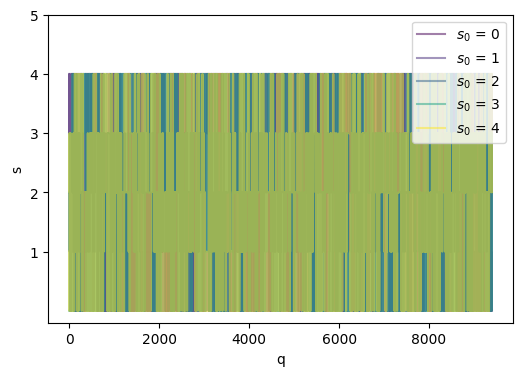

In [5]:
import matplotlib as mpl
cutout = 600
num_starts = 5
temp_indices = np.load(output_dir / "temp_indices.npy", mmap_mode='r')[:, cutout:]
norm = mpl.colors.Normalize(vmin=min(pt_config['bs'][0:num_starts]), vmax=max(pt_config['bs'][0:num_starts]))
cmap = plt.cm.viridis
print(temp_indices)
print(np.shape(temp_indices))
plt.figure(figsize=(6, 4))
xmin = 0
xmax = len(temp_indices[0, :])
# for i in range(len(temp_indices)):
plt.hlines(np.linspace(0, pt_config["nt"] - 1, pt_config["nt"]), linestyle = '--', color = "grey", linewidth = 0.1,  xmin = xmin, xmax = xmax)
for i in range(0, num_starts):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    plt.plot(np.arange(xmin, xmax, 1), temp_indices_i[xmin:xmax], label = r"$s_0$" + f" = {i}", color = cmap(norm(pt_config['bs'][i])), alpha = 0.5)  
print(temp_indices)
plt.yticks(np.linspace(1, pt_config["nt"], pt_config["nt"]))
plt.ylabel("s")
plt.xlabel("q")
plt.legend(loc = "upper right")
plt.savefig(f"{output_dir}/index_evolution.jpg")
plt.show()


In [6]:
backwards = False
round_trip = 0
num_temps = len(temp_indices)
num_samples = len(temp_indices[0, cutout:])
for chain in range(num_temps):
    for col in range(num_samples):
        if temp_indices[0, col] == chain and backwards:
            round_trip+=1
            backwards = False
        if temp_indices[-1, col] == chain:
            backwards = True
print(round_trip / (num_samples * num_temps))


0.011203272355414157


In [7]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [8]:
import arviz as az
ess_array = np.array([az.ess(samples[-1, :, i], method = "bulk") for i in range(len(samples[-1, 0, :]))])
print(ess_array)
min_ess = np.min(ess_array)
print(min_ess)

[1586.47566433 1563.65926983 1423.52328429 1595.374718   1326.38388992
 1690.4209858  1572.45954535 1907.79094722 1415.90783473 1426.29275103
 1399.20860074 2037.09697386 2422.59357138 2038.88370218 1993.97097197
 3304.65110539 3239.86886762 2966.24919251 2655.13850883 2769.2950955
 2762.48309854 1754.70616451 1279.22061798 1802.22438169 1896.7662231
 1401.88616756 1317.3409886  1839.45474675 1577.97485914 1739.21947291
 1570.51694274 1640.24350945 1550.48033355 1317.95938526  993.35089458
 1127.11082663  808.98730913 1581.36591822 1412.34871372 1532.56180363
 1790.87777053 2209.65381846 2055.12473702 1724.55254405 1989.5892752
 2164.24728956 1915.19867616 1934.45528564 2185.20061874 1827.01031536]
808.9873091336622


In [9]:
energy_values = np.load(output_dir / "energy.npy", mmap_mode='r')[:, cutout:]
d18o_energy_values = np.load(output_dir / "d18o_energy.npy", mmap_mode='r')[:, cutout:]

In [10]:
for i in range(0, pt_config["nt"] - 1):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    print(np.min(temp_indices_i))
    rej_indices = np.where((np.diff(temp_indices_i) == 0) & (temp_indices_i[:-1] != pt_config["nt"] - 1))[0]
    print(rej_indices)
    rej = 0
    for j in range(len(rej_indices)):
        rej+= 1 - np.min([1, np.exp((pt_config["bs"][temp_indices_i[rej_indices][j] + 1] - pt_config["bs"][temp_indices_i[rej_indices][j]]) * (d18o_energy_values[temp_indices_i[rej_indices][j] + 1, rej_indices][j] - d18o_energy_values[temp_indices_i[rej_indices][j], rej_indices][j]))])
    print(rej / pt_config["hmcc"]["ns"])

0
[   0    6    7 ... 9393 9394 9399]
0.2704806070331173
0
[   2   52   62 ... 9397 9398 9399]
0.2571071966691994
0
[   0    1    2 ... 9389 9392 9394]
0.2744274376906435
0
[   0    1    5 ... 9397 9398 9399]
0.2913889304978028


In [11]:
print(d18o_energy_values)

[[125.55310989 114.23060311 123.8845166  ... 111.5298494  124.92088584
  135.65363392]
 [111.93764341 103.44136264  94.40410521 ... 101.77084298 105.32595283
  116.15688278]
 [ 98.8743167  100.23957711 105.04146597 ...  94.64724156  93.97969109
   94.59718788]
 [ 92.81687246  94.92180605  91.07176021 ...  91.90287453 104.27279408
   89.61758173]
 [ 95.3558305   94.68426351  85.94998866 ...  97.29213454  87.78141427
   86.41199029]]


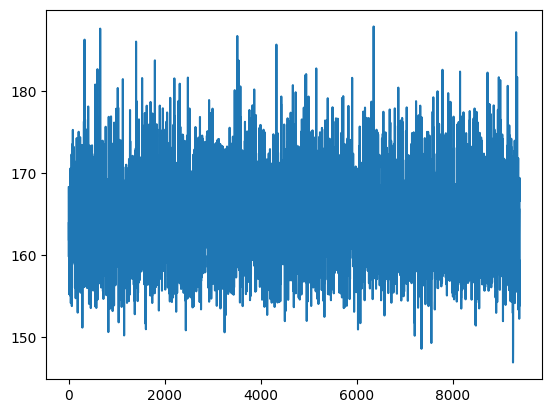

In [12]:
plt.figure()
chain = -1
plt.plot(energy_values[chain] - (pt_config["bs"][chain] - 1) * d18o_energy_values[chain])
plt.show()

In [13]:
# chain = -1
# fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([0], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
# ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
# plt.xlabel("Distance from top of stalagmite [" + measure + "]")
# plt.ylabel("Year CE")
# plt.legend()
# plt.savefig(f"{output_dir}/max_prob_sol.jpg")
# plt.show()

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
# ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
# for i, c in enumerate(data["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
# plt.xlabel("Distance from top of stalagmite [" + measure + "]")
# plt.ylabel("Year CE")
# plt.legend()
# plt.savefig(f"{output_dir}/close_prob_sol.jpg")
# plt.show()

In [18]:
index = 36
interesting_depth = index * data["dc"]

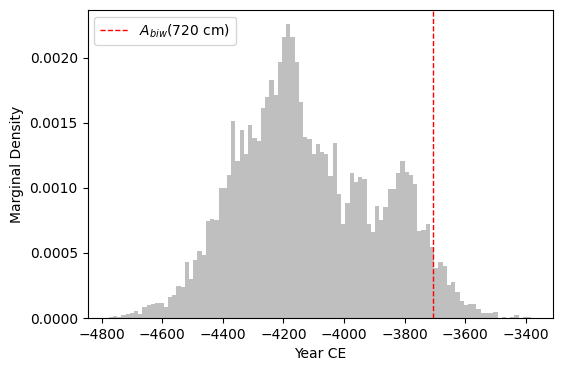

In [19]:
CV_values = data["th"] - data["dc"] * np.sum(samples[-1, :, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} " + measure + ")")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

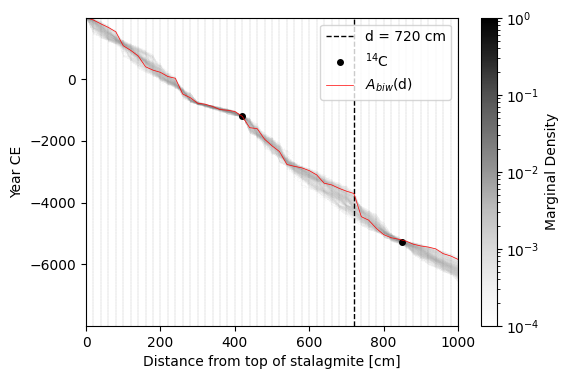

15011

In [20]:
from matplotlib import colors

X = samples[-1, :, :].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if "biw" not in data["dn"] else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1 if "biw" not in data["dn"] else 1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure)
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm(1e-4, 1),
    interpolation="nearest",
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()


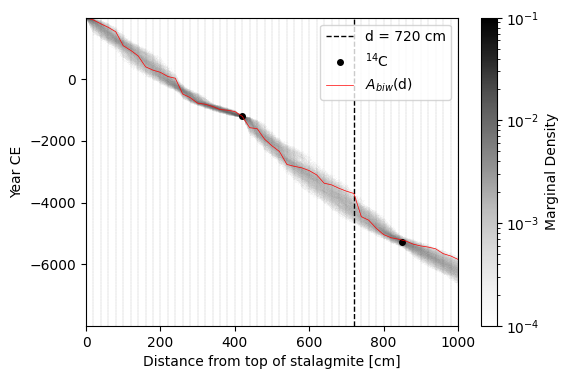

18484

In [21]:
from matplotlib import colors

X = samples[0, :, :].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if "biw" not in data["dn"] else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1 if "biw" not in data["dn"] else 1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} " + measure)
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["cs"], true_ages, color = "red", linewidth=0.5, alpha = 1, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm(1e-4, 1e-1),
    interpolation = "nearest",
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/sampled_no_mean.jpg")
plt.show()

del A, C
gc.collect()
